# k-NN e a maldição da dimensionalidade

**Tema:** Aprendizado Supervisionado › k-NN e Naive Bayes

Este notebook implementa k-NN do zero, confirma a necessidade de
padronização, visualiza o trade-off viés-variância na escolha de $k$, e
termina medindo diretamente a maldição da dimensionalidade — o fenômeno
pelo qual "vizinho mais próximo" perde sentido em muitas dimensões.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(11)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. k-NN do zero

In [2]:
def knn_prever(X_treino, y_treino, X_novo, k):
    previsoes = []
    for ponto in X_novo:
        distancias = np.linalg.norm(X_treino - ponto, axis=1)
        indices_vizinhos = np.argsort(distancias)[:k]
        vizinhos_classes = y_treino[indices_vizinhos]
        previsoes.append(scipy_stats.mode(vizinhos_classes, keepdims=False).mode)
    return np.array(previsoes)


n = 300
X_treino = rng.normal(0, 1, (n, 2))
y_treino = ((X_treino[:, 0] ** 2 + X_treino[:, 1] ** 2) < 1.2).astype(int)  # círculo
X_teste = rng.normal(0, 1.5, (100, 2))

pred_manual = knn_prever(X_treino, y_treino, X_teste, k=5)
pred_sklearn = KNeighborsClassifier(n_neighbors=5).fit(X_treino, y_treino).predict(X_teste)

print(f"concordância entre implementação manual e sklearn: "
      f"{(pred_manual == pred_sklearn).mean():.1%}")

concordância entre implementação manual e sklearn: 100.0%


## 2. Por que padronizar é obrigatório

In [3]:
n = 600
idade = rng.normal(40, 10, n)
renda = rng.normal(5000, 2000, n)
# a classe depende das DUAS variáveis de forma parecida (em unidades padronizadas)
idade_z = (idade - idade.mean()) / idade.std()
renda_z = (renda - renda.mean()) / renda.std()
classe = ((idade_z + renda_z) > 0).astype(int)

X_bruto = np.column_stack([idade, renda])
X_padronizado = StandardScaler().fit_transform(X_bruto)

acc_bruto = cross_val_score(KNeighborsClassifier(n_neighbors=15), X_bruto, classe, cv=5).mean()
acc_padronizado = cross_val_score(
    KNeighborsClassifier(n_neighbors=15), X_padronizado, classe, cv=5).mean()

print(f"acurácia (5-fold) SEM padronizar : {acc_bruto:.4f}")
print(f"acurácia (5-fold) COM padronizar : {acc_padronizado:.4f}")
print(f"\nrenda tem desvio-padrão ~{renda.std():.0f}, idade ~{idade.std():.1f} —")
print("sem padronizar, a distância é dominada quase inteiramente pela renda.")

acurácia (5-fold) SEM padronizar : 0.7267
acurácia (5-fold) COM padronizar : 0.9700

renda tem desvio-padrão ~1986, idade ~10.2 —
sem padronizar, a distância é dominada quase inteiramente pela renda.


## 3. Escolhendo k: viés-variância na prática

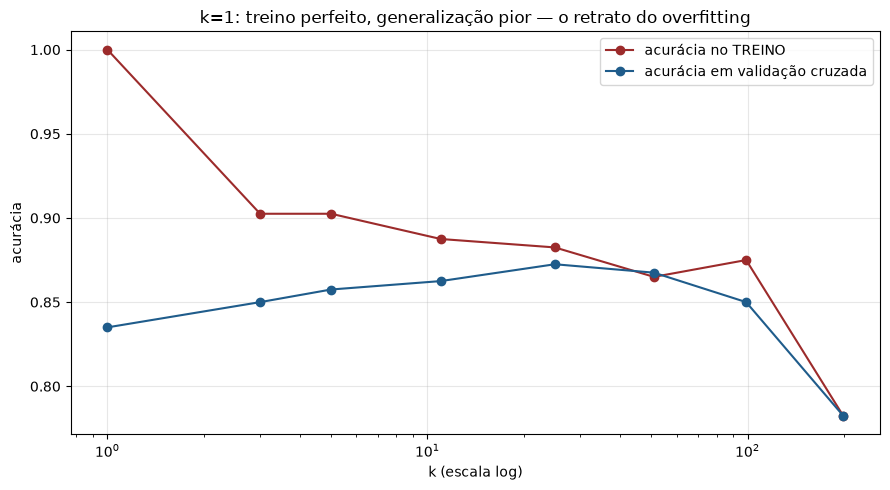

k que maximiza acurácia em validação cruzada: 25


In [4]:
n = 400
X = rng.uniform(-3, 3, (n, 2))
prob_real = 1 / (1 + np.exp(-(X[:, 0] ** 2 - X[:, 1])))
y = (rng.random(n) < prob_real).astype(int)

valores_k = [1, 3, 5, 11, 25, 51, 99, 199]
acc_treino, acc_cv = [], []
for k in valores_k:
    modelo = KNeighborsClassifier(n_neighbors=k).fit(X, y)
    acc_treino.append(modelo.score(X, y))
    acc_cv.append(cross_val_score(modelo, X, y, cv=5).mean())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(valores_k, acc_treino, "o-", color=VERMELHO, label="acurácia no TREINO")
ax.plot(valores_k, acc_cv, "o-", color=AZUL, label="acurácia em validação cruzada")
ax.set_xscale("log")
ax.set_xlabel("k (escala log)"); ax.set_ylabel("acurácia")
ax.set_title("k=1: treino perfeito, generalização pior — o retrato do overfitting")
ax.legend(); plt.tight_layout(); plt.show()

k_otimo = valores_k[np.argmax(acc_cv)]
print(f"k que maximiza acurácia em validação cruzada: {k_otimo}")

**Confirmação direta do `teoria.pdf`:** com $k=1$, a acurácia de treino é
exatamente 1.0 (cada ponto é seu próprio vizinho mais próximo) — mas a
acurácia em validação cruzada não é a melhor. O k ótimo fica em algum ponto
intermediário, nem $k=1$ nem o maior $k$ testado.

## 4. Fronteiras de decisão: k pequeno vs. k grande

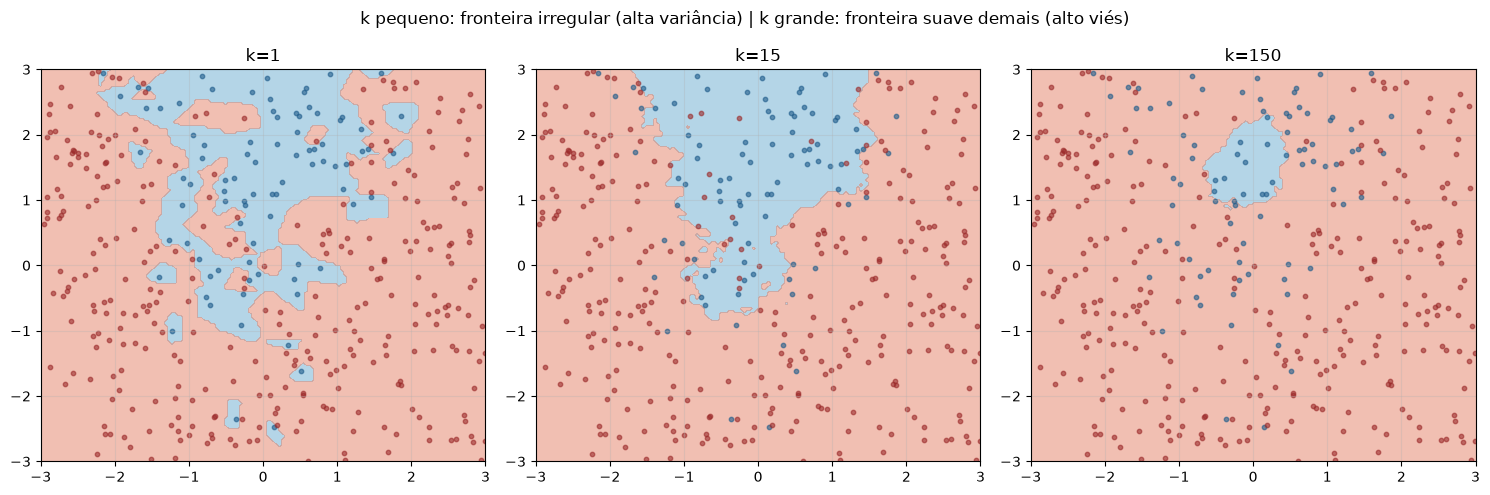

In [5]:
xx, yy = np.meshgrid(np.linspace(-3, 3, 150), np.linspace(-3, 3, 150))
grade = np.column_stack([xx.ravel(), yy.ravel()])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, k in zip(axes, [1, 15, 150]):
    modelo = KNeighborsClassifier(n_neighbors=k).fit(X, y)
    pred_grade = modelo.predict(grade).reshape(xx.shape)
    ax.contourf(xx, yy, pred_grade, levels=1, cmap="RdBu_r", alpha=0.5)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=10, color=AZUL, alpha=0.6)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=10, color=VERMELHO, alpha=0.6)
    ax.set_title(f"k={k}")
plt.suptitle("k pequeno: fronteira irregular (alta variância) | "
             "k grande: fronteira suave demais (alto viés)")
plt.tight_layout(); plt.show()

## 5. A maldição da dimensionalidade, medida diretamente

Vamos gerar pontos aleatórios em cubos de dimensão crescente e medir a
razão entre a distância do vizinho MAIS PRÓXIMO e do MAIS DISTANTE a partir
de um ponto de referência. Se essa razão se aproxima de 1, "mais próximo" e
"mais distante" ficam praticamente indistinguíveis.

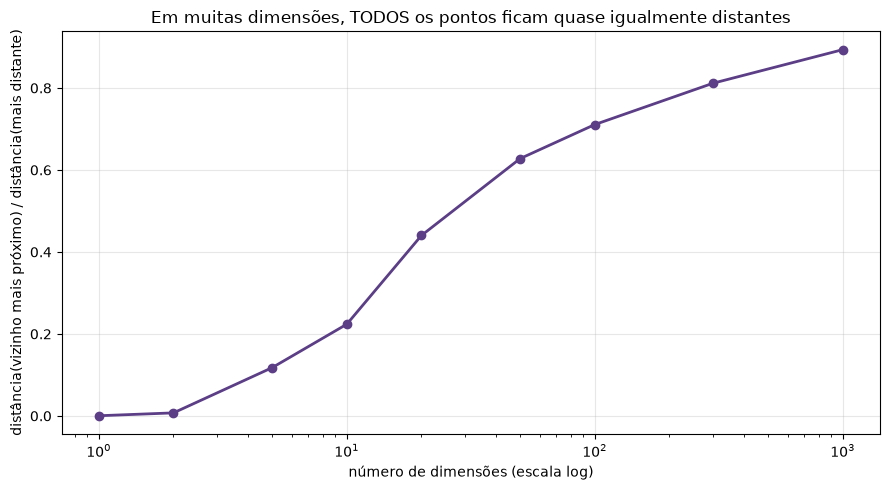

 dimensões    razão mín/máx
----------------------------
         1           0.0004
         2           0.0074
         5           0.1177
        10           0.2237
        20           0.4403
        50           0.6278
       100           0.7108
       300           0.8117
      1000           0.8936


In [6]:
def razao_distancias(dimensao, n_pontos=1000, seed=0):
    rng_local = np.random.default_rng(seed)
    pontos = rng_local.uniform(0, 1, (n_pontos, dimensao))
    referencia = rng_local.uniform(0, 1, dimensao)
    distancias = np.linalg.norm(pontos - referencia, axis=1)
    return distancias.min() / distancias.max()


dimensoes = [1, 2, 5, 10, 20, 50, 100, 300, 1000]
razoes = [razao_distancias(d) for d in dimensoes]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dimensoes, razoes, "o-", color=ROXO, lw=2)
ax.set_xscale("log")
ax.set_xlabel("número de dimensões (escala log)")
ax.set_ylabel("distância(vizinho mais próximo) / distância(mais distante)")
ax.set_title("Em muitas dimensões, TODOS os pontos ficam quase igualmente distantes")
plt.tight_layout(); plt.show()

print(f"{'dimensões':>10s} {'razão mín/máx':>16s}")
print("-" * 28)
for d, r in zip(dimensoes, razoes):
    print(f"{d:>10d} {r:>16.4f}")

**A razão se aproxima de 1** conforme a dimensão cresce — o ponto mais
próximo e o mais distante ficam quase à mesma distância do ponto de
referência. "Vizinho mais próximo" deixa de ser um conceito discriminativo
nesse regime, o que explica por que k-NN degrada silenciosamente em
datasets com muitas features, mesmo que a maioria delas seja irrelevante.

## O que levar deste notebook

- k-NN não tem fase de treino real — todo o trabalho acontece no momento
  da previsão, comparando contra o dataset de treino inteiro.
- Padronização não é opcional: sem ela, a feature de maior escala numérica
  domina a distância sozinha.
- $k$ pequeno tem baixo viés e alta variância (overfitting); $k$ grande, o
  oposto — o valor ótimo vem de validação cruzada, nunca de um palpite.
- Em dimensões altas, a própria noção de "vizinho mais próximo" perde
  poder discriminativo — a maldição da dimensionalidade é mensurável, não
  só uma frase de efeito.

→ Próximo: **Naive Bayes**, o outro extremo — um modelo que assume
independência total entre features.